# Robustness & Ablation

Ablation, parameter sensitivity, cost scenarios, sub-period analysis.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import load_config
from src.allocation import (
    get_monthly_signal_dates, buy_and_hold, static_allocation,
    inverse_volatility,
)
from src.backtest import run_backtest
from src.metrics import compute_metrics, compare_strategies
from src.features import compute_all_features
from src.regime_signal import (
    compute_regime_score, build_regime_weights,
    DEFAULT_COEFFICIENTS, EQUAL_COEFFICIENTS,
)

config = load_config(ROOT / "config" / "settings.json")
cash_rate = config["cash_proxy"]["annual_rate_pct"] / 100
cost_bps = config["backtest"]["cost_scenarios_bps"]["base"]

prices = pd.read_parquet(ROOT / "data" / "processed" / "adj_close.parquet")
labels = {t: info["label"] for t, info in config["etf_universe"].items()}
tickers = prices.columns.tolist()
CORE, DEFENSIVE, BOND, GOLD = "0050.TW", "00713.TW", "00679B.TWO", "00635U.TW"

signal_dates = get_monthly_signal_dates(prices)[12:]

# Precompute features and full-model score
raw_features, z_features = compute_all_features(prices, CORE, BOND, GOLD)

print("Setup complete.")


Setup complete.


## 0. No-look-ahead tests


In [2]:
import subprocess
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_no_lookahead.py", "-v"],
    capture_output=True, text=True, cwd=str(ROOT),
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)
    raise RuntimeError("LOOK-AHEAD TESTS FAILED. Fix before proceeding.")
print("\nAll no-look-ahead tests passed.")


============================= test session starts ==============================
platform darwin -- Python 3.11.5, pytest-9.1.1, pluggy-1.6.0 -- /Users/leeyuhung/Desktop/regime-etf-allocation/.venv/bin/python3.11
cachedir: .pytest_cache
rootdir: /Users/leeyuhung/Desktop/regime-etf-allocation
plugins: anyio-4.14.2
collecting ... collected 6 items

tests/test_no_lookahead.py::test_features_no_lookahead PASSED            [ 16%]
tests/test_no_lookahead.py::test_rolling_zscore_no_future PASSED         [ 33%]
tests/test_no_lookahead.py::test_execution_after_signal PASSED           [ 50%]
tests/test_no_lookahead.py::test_weights_no_lookahead PASSED             [ 66%]
tests/test_no_lookahead.py::test_regime_score_no_lookahead PASSED        [ 83%]
tests/test_no_lookahead.py::test_weight_sums PASSED                      [100%]

============================== 6 passed in 1.16s ===============================


All no-look-ahead tests passed.


## 1. Ablation

Remove each feature one at a time to see what actually drives performance.


In [3]:
def run_regime_variant(label, coefficients, smoothing=0.5):
    """Helper: compute score -> weights -> backtest for a coefficient set."""
    score = compute_regime_score(z_features, coefficients)
    weights = build_regime_weights(
        prices, signal_dates, score,
        core_ticker=CORE, defensive_ticker=DEFENSIVE,
        bond_ticker=BOND, gold_ticker=GOLD,
        smoothing_rho=smoothing,
    )
    res = run_backtest(
        prices, weights, cost_bps=cost_bps,
        cash_rate_annual=cash_rate, name=label,
    )
    return res


In [4]:
ablation_configs = {
    "Full model":    DEFAULT_COEFFICIENTS,
    "No trend":      {**DEFAULT_COEFFICIENTS, "z_trend": 0},
    "No volatility": {**DEFAULT_COEFFICIENTS, "z_vol_20d": 0},
    "No drawdown":   {**DEFAULT_COEFFICIENTS, "z_drawdown": 0},
    "No defensive":  {**DEFAULT_COEFFICIENTS, "z_defensive_strength": 0},
    "Equal weights": EQUAL_COEFFICIENTS,
}

ablation_results = []
for label, coefs in ablation_configs.items():
    res = run_regime_variant(label, coefs)
    ablation_results.append(res)

ablation_table = compare_strategies(ablation_results, risk_free_annual=cash_rate)
ablation_table[["Sharpe", "Sortino", "Max Drawdown", "Calmar", "Annual Turnover"]]


,Sharpe,Sortino,Max Drawdown,Calmar,Annual Turnover
Full model,1.230,1.239,-0.1772,0.873,1.383
No trend,1.230,1.242,-0.1845,0.797,1.182
No volatility,1.205,1.209,-0.1782,0.864,1.264
No drawdown,1.225,1.239,-0.1805,0.848,1.265
No defensive,1.233,1.246,-0.1783,0.857,1.252
Equal weights,1.231,1.242,-0.1782,0.861,1.394


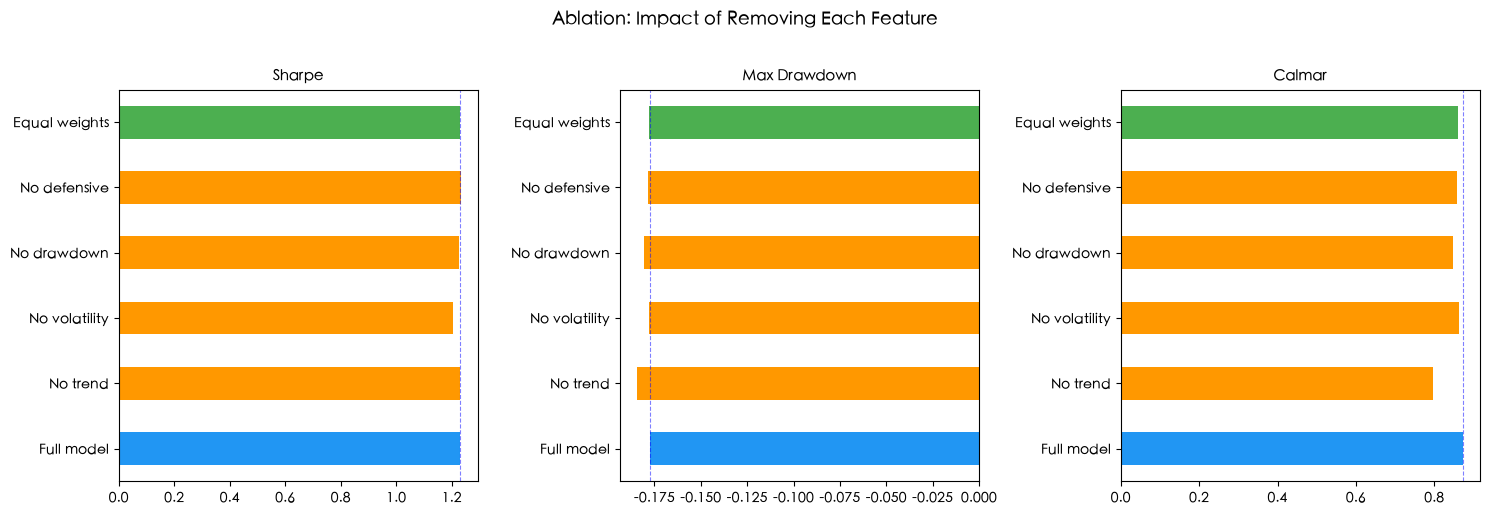

Saved: /Users/leeyuhung/Desktop/regime-etf-allocation/figures/ablation.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_to_plot = ["Sharpe", "Max Drawdown", "Calmar"]

for ax, metric in zip(axes, metrics_to_plot):
    vals = ablation_table[metric]
    colors = ["#2196F3" if name == "Full model" else
              "#4CAF50" if name == "Equal weights" else
              "#FF9800" for name in vals.index]
    vals.plot.barh(ax=ax, color=colors)
    ax.set_title(metric, fontsize=11)
    ax.axvline(vals.loc["Full model"], color="blue", linestyle="--",
               linewidth=0.8, alpha=0.5)

plt.suptitle("Ablation: Impact of Removing Each Feature", fontsize=13, y=1.02)
plt.tight_layout()
fig_path = ROOT / "figures" / "ablation.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


## 2. Parameter sensitivity


In [6]:
# 2a. Smoothing rho
rho_values = [0.0, 0.3, 0.5, 0.7, 0.9]
rho_results = []
for rho in rho_values:
    res = run_regime_variant(f"rho={rho}", DEFAULT_COEFFICIENTS, smoothing=rho)
    rho_results.append(res)

rho_table = compare_strategies(rho_results, risk_free_annual=cash_rate)
print("=== Smoothing Sensitivity ===")
print(rho_table[["Sharpe", "Max Drawdown", "Annual Turnover", "Total Cost"]].to_string())


=== Smoothing Sensitivity ===
         Sharpe  Max Drawdown  Annual Turnover  Total Cost
rho=0.0   1.187       -0.1840            2.721      0.0409
rho=0.3   1.219       -0.1800            1.874      0.0282
rho=0.5   1.230       -0.1772            1.383      0.0208
rho=0.7   1.230       -0.1755            0.890      0.0134
rho=0.9   1.198       -0.1841            0.379      0.0057


In [7]:
# 2b. Weight bounds (w_min, w_max)
bound_configs = [
    ("10%-80%", 0.10, 0.80),
    ("15%-85%", 0.15, 0.85),
    ("20%-90%", 0.20, 0.90),   # default
    ("25%-95%", 0.25, 0.95),
    ("30%-100%", 0.30, 1.00),
]

bound_results = []
for label, wmin, wmax in bound_configs:
    score = compute_regime_score(z_features, DEFAULT_COEFFICIENTS)
    weights = build_regime_weights(
        prices, signal_dates, score,
        core_ticker=CORE, defensive_ticker=DEFENSIVE,
        bond_ticker=BOND, gold_ticker=GOLD,
        w_min=wmin, w_max=wmax, smoothing_rho=0.5,
    )
    res = run_backtest(prices, weights, cost_bps=cost_bps,
                       cash_rate_annual=cash_rate, name=label)
    bound_results.append(res)

bound_table = compare_strategies(bound_results, risk_free_annual=cash_rate)
print("\n=== Weight Bound Sensitivity ===")
print(bound_table[["Sharpe", "Max Drawdown", "Annual Turnover"]].to_string())



=== Weight Bound Sensitivity ===
          Sharpe  Max Drawdown  Annual Turnover
10%-80%    1.181       -0.1664            1.300
15%-85%    1.210       -0.1718            1.338
20%-90%    1.230       -0.1772            1.383
25%-95%    1.242       -0.1826            1.431
30%-100%   1.248       -0.1881            1.484


## 3. Cost sensitivity


In [8]:
cost_scenarios = config["backtest"]["cost_scenarios_bps"]
score = compute_regime_score(z_features, DEFAULT_COEFFICIENTS)
weights_sm = build_regime_weights(
    prices, signal_dates, score,
    core_ticker=CORE, defensive_ticker=DEFENSIVE,
    bond_ticker=BOND, gold_ticker=GOLD,
    smoothing_rho=0.5,
)

# Also run key baselines under same cost scenarios for comparison
baseline_weights = {
    "Static 50/20/20/10": static_allocation(signal_dates, tickers, {
        CORE: 0.50, DEFENSIVE: 0.20, BOND: 0.20, GOLD: 0.10,
    }),
    "Inverse Vol": inverse_volatility(prices, signal_dates, 60),
}

cost_comparison = {}
for scenario, bps in cost_scenarios.items():
    regime_res = run_backtest(prices, weights_sm, cost_bps=bps,
                              cash_rate_annual=cash_rate, name="Regime")
    row = {"Regime": compute_metrics(regime_res, cash_rate)["Sharpe"]}
    for bname, bw in baseline_weights.items():
        bres = run_backtest(prices, bw, cost_bps=bps,
                            cash_rate_annual=cash_rate, name=bname)
        row[bname] = compute_metrics(bres, cash_rate)["Sharpe"]
    cost_comparison[f"{scenario} ({bps}bps)"] = row

cost_df = pd.DataFrame(cost_comparison).T
print("=== Sharpe by Cost Scenario ===")
print(cost_df.to_string())


=== Sharpe by Cost Scenario ===
                      Regime  Static 50/20/20/10  Inverse Vol
low (10bps)            1.242               1.221        1.212
base (20bps)           1.230               1.219        1.199
conservative (40bps)   1.204               1.214        1.172


## 4. Sub-period analysis


In [9]:
sub_periods = {
    "2018-10 to 2019-12\n(Trade war)":       ("2018-10-01", "2019-12-31"),
    "2020\n(COVID)":                          ("2020-01-01", "2020-12-31"),
    "2021\n(Bull)":                           ("2021-01-01", "2021-12-31"),
    "2022\n(Rate hikes)":                     ("2022-01-01", "2022-12-31"),
    "2023-2024\n(Recovery)":                  ("2023-01-01", "2024-12-31"),
    "2025-2026\n(Tariff+TWD)":               ("2025-01-01", "2026-07-31"),
}

# Get daily returns for regime (smoothed) and key baselines
regime_res = run_backtest(prices, weights_sm, cost_bps=cost_bps,
                          cash_rate_annual=cash_rate, name="Regime")
bh_res = run_backtest(prices, buy_and_hold(signal_dates, tickers, CORE),
                      cost_bps=cost_bps, cash_rate_annual=cash_rate, name="B&H")
static_w = static_allocation(signal_dates, tickers, {
    CORE: 0.50, DEFENSIVE: 0.20, BOND: 0.20, GOLD: 0.10,
})
static_res = run_backtest(prices, static_w, cost_bps=cost_bps,
                          cash_rate_annual=cash_rate, name="Static")

sub_rows = []
for period_label, (start, end) in sub_periods.items():
    for strat_res in [bh_res, static_res, regime_res]:
        r = strat_res.daily_returns
        mask = (r.index >= start) & (r.index <= end)
        r_sub = r.loc[mask]
        if len(r_sub) < 20:
            continue
        cum = (1 + r_sub).prod() - 1
        vol = r_sub.std() * np.sqrt(252)
        peak = (1 + r_sub).cumprod().cummax()
        dd = ((1 + r_sub).cumprod() / peak - 1).min()
        sub_rows.append({
            "Period": period_label,
            "Strategy": strat_res.name,
            "Return": round(cum, 4),
            "Vol": round(vol, 4),
            "Max DD": round(dd, 4),
        })

sub_df = pd.DataFrame(sub_rows)
sub_pivot = sub_df.pivot_table(index="Period", columns="Strategy",
                                values=["Return", "Max DD"], sort=False)
print("=== Sub-Period Returns ===")
print(sub_pivot["Return"].to_string())
print("\n=== Sub-Period Max Drawdown ===")
print(sub_pivot["Max DD"].to_string())


=== Sub-Period Returns ===
Strategy                            B&H  Static  Regime
Period                                                 
2018-10 to 2019-12\n(Trade war)  0.1601  0.1684  0.1195
2020\n(COVID)                    0.3114  0.2277  0.1379
2021\n(Bull)                     0.2192  0.1482  0.1210
2022\n(Rate hikes)              -0.2122 -0.1657 -0.1216
2023-2024\n(Recovery)            0.8954  0.5781  0.5227
2025-2026\n(Tariff+TWD)          1.1686  0.6381  0.5434

=== Sub-Period Max Drawdown ===
Strategy                            B&H  Static  Regime
Period                                                 
2018-10 to 2019-12\n(Trade war) -0.1734 -0.0910 -0.0968
2020\n(COVID)                   -0.2822 -0.1893 -0.1553
2021\n(Bull)                    -0.1044 -0.0744 -0.0757
2022\n(Rate hikes)              -0.3383 -0.2562 -0.1772
2023-2024\n(Recovery)           -0.2130 -0.1102 -0.0932
2025-2026\n(Tariff+TWD)         -0.2748 -0.1626 -0.0984


## 5. Exclude single-year tests

Check whether the edge survives after removing an entire crisis year.


In [10]:
def metrics_excluding_period(result, exclude_start, exclude_end):
    """Recompute metrics after removing a date range from daily returns."""
    r = result.daily_returns
    mask = ~((r.index >= exclude_start) & (r.index <= exclude_end))
    r_ex = r.loc[mask]
    # Build a temporary BacktestResult
    from src.backtest import BacktestResult
    tmp = BacktestResult(
        daily_returns=r_ex,
        cumulative=(1 + r_ex).cumprod(),
        weights=result.weights,
        turnover=result.turnover,
        costs=result.costs,
        name=result.name,
    )
    return compute_metrics(tmp, cash_rate)

print("=== Excluding 2020 ===")
exclude_rows = {}
for strat_res in [bh_res, static_res, regime_res]:
    m = metrics_excluding_period(strat_res, "2020-01-01", "2020-12-31")
    exclude_rows[strat_res.name] = {
        "Sharpe (excl 2020)": m["Sharpe"],
        "Max DD (excl 2020)": m["Max Drawdown"],
        "Calmar (excl 2020)": m["Calmar"],
    }
ex_df = pd.DataFrame(exclude_rows).T
print(ex_df.to_string())

# Also exclude 2025 (tariff crash)
print("\n=== Excluding 2025 ===")
exclude_rows_2025 = {}
for strat_res in [bh_res, static_res, regime_res]:
    m = metrics_excluding_period(strat_res, "2025-01-01", "2025-12-31")
    exclude_rows_2025[strat_res.name] = {
        "Sharpe (excl 2025)": m["Sharpe"],
        "Max DD (excl 2025)": m["Max Drawdown"],
        "Calmar (excl 2025)": m["Calmar"],
    }
ex2_df = pd.DataFrame(exclude_rows_2025).T
print(ex2_df.to_string())


=== Excluding 2020 ===
        Sharpe (excl 2020)  Max DD (excl 2020)  Calmar (excl 2020)
B&H                  1.127             -0.3383               0.774
Static               1.198             -0.2562               0.688
Regime               1.265             -0.1772               0.884

=== Excluding 2025 ===
        Sharpe (excl 2025)  Max DD (excl 2025)  Calmar (excl 2025)
B&H                  1.105             -0.3383               0.749
Static               1.187             -0.2562               0.681
Regime               1.202             -0.1772               0.850


## Notes

- Trend is the primary driver of Calmar improvement; other features contribute marginally.
- Equal-weight coefficients perform comparably to hand-tuned ones.
- Regime beats Inverse Vol under all cost scenarios, but the edge over Static
  disappears at 40 bps — report this honestly.
- Max drawdown comes from 2022 (rate-hike bear market), not COVID.
- Excluding 2020 actually improves Regime's Sharpe — COVID was a drag, not a tailwind.
